# Numerisk derivasjon av $\ln Q$ i utregning av indre energi $U$

_Underveisoppgave_ - [Partisjonsfunksjonen og molekylær energi](https://andreasdh.github.io/Bifrost/docs/partisjonsfunksjonen.html#partisjonsfunksjonen)

I denne oppgaven er systemet vårt et molekyl med to energinivåer: en grunntilstand med energi $E_0 = 0$ og en eksitert tilstand med energi $E_1 = \varepsilon$, der $\varepsilon = 5{.}0 \times 10^{-21}\ \text{J}$. Partisjonsfunksjonen blir dermed 

$Q = \sum_i e^{-E_i/k_BT} = e^{-0/k_BT} + e^{-\varepsilon/k_BT} = 1 + e^{-\varepsilon/k_BT}$

Du skal bruke sentraldifferansen til å estimere den indre energien $U = k_BT^2\,\frac{\partial \ln Q}{\partial T}$ numerisk ved temperaturene $T = 100, 200, 300, 500$ og $1000\ \text{K}$, og deretter plotte sammenhengen. Det skal gjøres i det påegynte Python-scriptet nedenfor.

**a)** Hva gjør funksjonene ``lnQ(T)`` og ``indre_energi(T, h=1e-3)``?

**b)** Lag en liste ``T`` med temperaturene, og en tom liste ``U`` som vi skal bruke til de indre energiene.

**c)** Lag en løkke som går over hver temperatur i ``T``. Skriv kode som gjør følgende for hver temperatur i løkka:

- Estimerer den indre energien for temperaturen ved bruk av ``indre_energi()``-funksjonen.

- Legger den indre energien til i ``U``

- Printer temperaturen med den indre energien som du estimerte pent, med enheter.

**d)** Plott indre energi mot temperatur. Husk tittel og aksetitler med enheter. Hva kan du si om sammenhengen mellom indre energi og temperatur?

**Utfordring**: Bruk formelen for $U$ ved partisjonsfunksjonen $Q$ og energiene $E_i$ til å finne grenseverdien til $U$ når $T \to \infty$. Hva betyr denne verdien?

In [246]:
import numpy as np
import matplotlib.pyplot as plt

kB = 1.38e-23   # Boltzmanns konstant, J/K
eps = 5.0e-21       # energigapet mellom nivåene, J

# Funksjon som tar den naturlige logaritmen av Q for to-nivåsystemet
def lnQ(T):
    return np.log(1 + np.exp(-eps/(kB*T)))

# Regner ut d(lnQ)/dT numerisk med sentraldifferansen (f(T+h) - f(T-h)) / (2h)
def indre_energi(T, h=1e-3):
    derivert = (lnQ(T + h) - lnQ(T - h)) / (2*h)
    return kB * T**2 * derivert

### BEGYNN KODEN DIN HER ###

### Løsningsforslag

**a)** Dette gjør funksjonene:

- ``lnQ(T)``

Funksjonen tar en temperatur ``T`` og returnerer den naturlige logaritmen av partisjonsfunksjonen for verdien av ``T``. 

- ``indre_energi(T, h=1e-3)``

Funksjonen tar en temperatur ``T`` og en steglengde ``h``, og returnerer den indre energien ved ``T``. Den deriverte av ``lnQ`` regnes numerisk med sentraldifferansen, og ganges med ``kB * T**2`` etter formelen for indre energi.


**b)** Se Python-script.

**c)** Se Python-script.

**d)** Se Python-script for koden. 

**Utfordring**: Vi finner grenseverdien når temperaturen går mot uendelig:

$\lim_{T\to\infty} U = \lim_{T\to\infty} \frac{\varepsilon}{1 + e^{\varepsilon/k_BT}} = \frac{\varepsilon}{1 + e^0} = \frac{\varepsilon}{2}$

At grenseverdien er $\varepsilon/2$ betyr at de to nivåene ved svært høye temperaturer er tilnærmet like befolket: halvparten av molekylene ligger i grunntilstanden ($E=0$) og halvparten i det øvre nivået ($E=\varepsilon$), så gjennomsnittsenergien blir midt imellom.

T = 100 K: U = 1.300e-22 J
T = 200 K: U = 7.022e-22 J
T = 300 K: U = 1.151e-21 J
T = 500 K: U = 1.632e-21 J
T = 1000 K: U = 2.052e-21 J


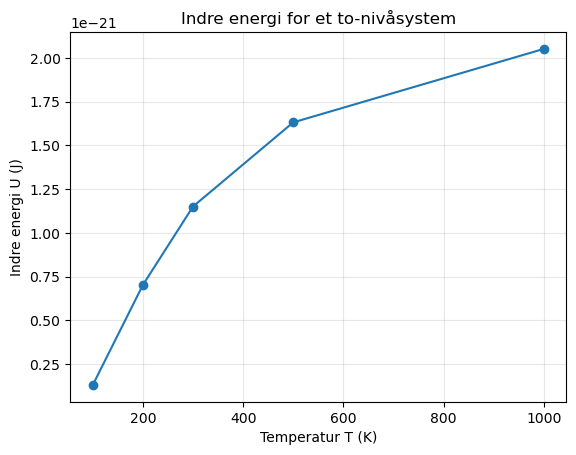

In [247]:
import numpy as np
import matplotlib.pyplot as plt

kB = 1.38e-23       # Boltzmanns konstant, J/K
eps = 5.0e-21       # energigapet mellom nivåene, J

# Funksjon som tar den naturlige logaritmen av Q for to-nivåsystemet
def lnQ(T):
    return np.log(1 + np.exp(-eps/(kB*T)))

# Regner ut d(lnQ)/dT numerisk med sentraldifferansen (f(T+h) - f(T-h)) / (2h)
def indre_energi(T, h=1e-3):
    derivert = (lnQ(T + h) - lnQ(T - h)) / (2*h)
    return kB * T**2 * derivert

##### BEGYNN KODEN DIN HER #####

# OPPGAVE B
T = [100, 200, 300, 500, 1000]   # Temperaturer i K
U = []                           # Tom liste til indre energier

# OPPGAVE C
for temp in T:
    u = indre_energi(temp)
    U.append(u)
    print(f"T = {temp} K: U = {u:.3e} J")

# OPPGAVE D
plt.plot(T, U, "-o")
plt.xlabel("Temperatur T (K)")
plt.ylabel("Indre energi U (J)")
plt.title("Indre energi for et to-nivåsystem")
plt.grid(alpha=0.3)
plt.show()

# En irreversibel ekspansjon nærmer seg en reversibel ekspansjon når vi deler inn i mange trinn

_Hjelpeplott_ - Gasser

En ideell gass ($n = 1.0\ \text{mol}$) ekspanderer isotermt ved $T = 298\ \text{K}$ fra $V_i = 1.0\ \text{L}$ til $V_f = 3.0\ \text{L}$. Arbeidet er $w = -\int P\,dV$. Ved en irreversibel ekspansjon mot konstant ytre trykk gjøres det mindre arbeid enn ved en reversibel, fordi gassen bare "presser mot" et lavt ytre trykk hele veien. Vi kan dele ekspansjonen i flere trinn, der det ytre trykket settes ned litt for hvert trinn. Vi skal regne ut det totale arbeidet for $1, 2, 4, 8, \dots$ trinn, og se at det nærmer seg det reversible arbeidet $w_{rev} = -nRT\ln(V_f/V_i)$ når antall trinn øker. En reversibel prosess er nettopp grensen med uendelig mange små trinn.

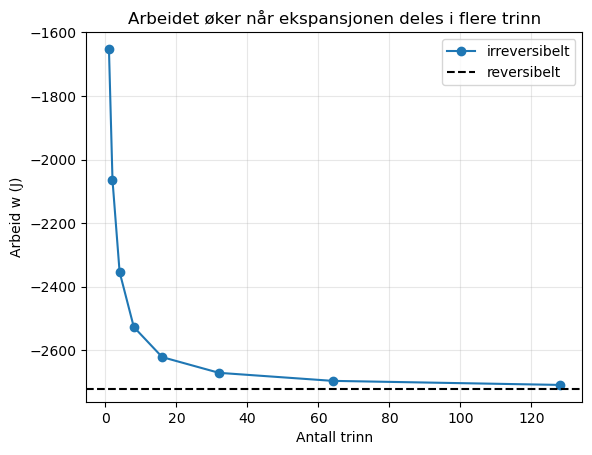

In [248]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314      # gasskonstanten, J/(mol K)
n = 1.0        # stoffmengde, mol
T = 298        # temperatur, K
Vi = 1.0e-3    # startvolum, m^3
Vf = 3.0e-3    # sluttvolum, m^3

# Gassens trykk (ideell gasslov)
def P(V):
    return n*R*T/V

# Regner ut irreversibelt arbeid for et gitt antall trinn
# I hvert trinn ekspanderer gassen mot konstant ytre trykk lik gassens trykk ved slutten av trinnet
def arbeid_trinn(n_trinn):
    kanter = np.linspace(Vi, Vf, n_trinn + 1)
    w = 0
    for i in range(n_trinn):
        P_ex = P(kanter[i+1])                 # ytre trykk i dette trinnet
        w += -P_ex*(kanter[i+1] - kanter[i])  # arbeid i dette trinnet
    return w

# Reversibelt arbeid (grensen med uendelig mange trinn)
w_rev = -n*R*T*np.log(Vf/Vi)

# Regn ut arbeidet for stadig flere trinn
trinn = [1, 2, 4, 8, 16, 32, 64, 128]
w_liste = []
for n_trinn in trinn:
    w = arbeid_trinn(n_trinn)
    w_liste.append(w)

# Plott: arbeidet som funksjon av antall trinn i integrasjonen
plt.plot(trinn, w_liste, "o-", label="irreversibelt")
plt.axhline(w_rev, color="k", linestyle="--", label="reversibelt")
plt.xlabel("Antall trinn")
plt.ylabel("Arbeid w (J)")
plt.title("Arbeidet øker når ekspansjonen deles i flere trinn")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Damptrykkurven for vann beregnet fra Clausius–Clapeyrons likning

_Hjelpeplott_ - Faser

Damptrykket til en væske øker med temperaturen ifølge Clausius-Clapeyrons likning, $P = P^* e^{-\chi}$ der $\chi = \frac{\Delta_{vap}H}{R}\left(\frac{1}{T} - \frac{1}{T^*}\right)$. For vann er $\Delta_{vap}H = 40.7\ \text{kJ/mol}$, med referansepunktet $T^* = 373.15\ \text{K}$ og $P^* = 1.013 \times 10^5\ \text{Pa}$. Vi skal regne ut damptrykket over et temperaturintervall og plotte kurven $P(T)$, og se at den treffer 1 atm ved kokepunktet.

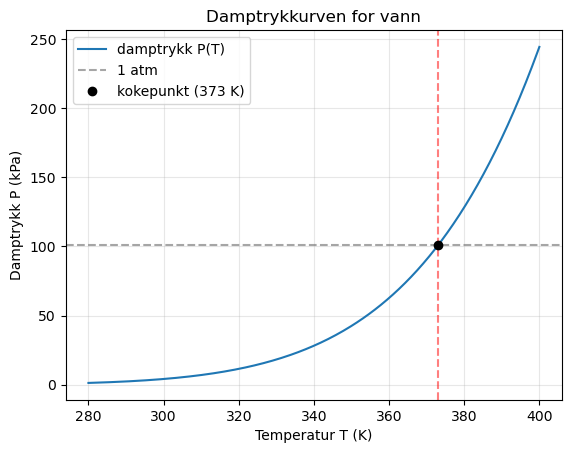

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314          # gasskonstanten, J/(mol K)
dHvap = 40.7e3     # fordampningsentalpi for vann, J/mol
Tstar = 373.15     # referansetemperatur (kokepunkt ved 1 atm), K
Pstar = 1.013e5    # damptrykk ved Tstar, Pa

# Clausius-Clapeyron: P = P* exp(-chi), chi = (dHvap/R)(1/T - 1/T*)
def P(T):
    chi = dHvap/R * (1/T - 1/Tstar)
    return Pstar*np.exp(-chi)

# Regn ut damptrykket over et temperaturintervall
T = np.linspace(280, 400, 300)
damptrykk = P(T)

atm = 1.013e5      # 1 atm i Pa

# Plott kurven, og marker 1 atm og kokepunktet
plt.plot(T, damptrykk/1000, label="damptrykk P(T)")
plt.axhline(atm/1000, color="gray", linestyle="--", alpha=0.7, label="1 atm")
plt.axvline(Tstar, color="red", linestyle="--", alpha=0.5)
plt.plot(Tstar, atm/1000, "ko", label="Kokepunkt (373 K)")
plt.xlabel("Temperatur T (K)")
plt.ylabel("Damptrykk P (kPa)")
plt.title("Damptrykkurven for vann")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bestemmelse av fordampningsentalpi fra damptrykksmålinger ved lineær tilpasning av Clausius–Clapeyron

Damptrykket til en væske er målt ved fire temperaturer: ved $T = 300, 320, 340$ og $360\ \text{K}$ er trykket henholdsvis $3.5, 10.5, 27.0$ og $62.0\ \text{kPa}$. På logaritmisk form er Clausius-Clapeyrons likning en rett linje

$\ln P = -\frac{\Delta_{vap}H}{R}\cdot\frac{1}{T} + \text{konstant}$

Vi kan plotte $\ln P$ mot $1/T$, tilpasse en rett linje til punktene, og finne fordampningsentalpien direkte fra stigningstallet $\Delta_{vap}H$ fra stigningstallet.

dHvap = 43.0 kJ/mol


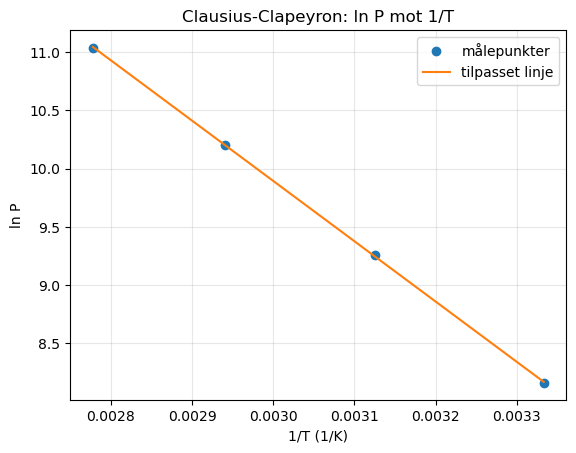

In [250]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314   # gasskonstanten, J/(mol K)

# Målt damptrykk ved noen temperaturer
Tdata = np.array([300, 320, 340, 360])      # K
Pdata = np.array([3.5e3, 10.5e3, 27.0e3, 62.0e3])  # Pa

# Clausius-Clapeyron på lineær form: ln P = -(dHvap/R)(1/T) + konstant
x = 1/Tdata
y = np.log(Pdata)
slope, intercept = np.polyfit(x, y, 1)

# Fordampningsentalpi fra stigningstallet
dHvap = -slope*R
print(f"dHvap = {dHvap/1000:.1f} kJ/mol")

plt.plot(x, y, "o", label="målepunkter")
plt.plot(x, slope*x + intercept, label="tilpasset linje")
plt.xlabel("1/T (1/K)")
plt.ylabel("ln P")
plt.title("Clausius-Clapeyron: ln P mot 1/T")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bestemmelse av faseovergangstemperatur fra kjemisk potensial og likvekt

To faser av et stoff har hvert sitt kjemiske potensial som synker med temperaturen ifølge $\mu(T) = \mu_0 - S_m(T - T_0)$, der $S_m$ er den molare entropien. Væsken har høyere entropi enn fast fase, så de to linjene krysser hverandre ved én bestemt temperatur. Ved denne temperaturen er $\mu_\text{fast} = \mu_\text{væske}$, altså er de to fasene i likevekt.

Vi skal finne denne faseovergangstemperaturen numerisk. Formuler likevektsbetingelsen som et nullpunktsproblem $f(T) = \mu_\text{fast}(T) - \mu_\text{væske}(T) = 0$, og bruk halveringsmetoden til å finne temperaturen der de to kjemiske potensialene er like.

Faseovergang ved T = 266.25 K


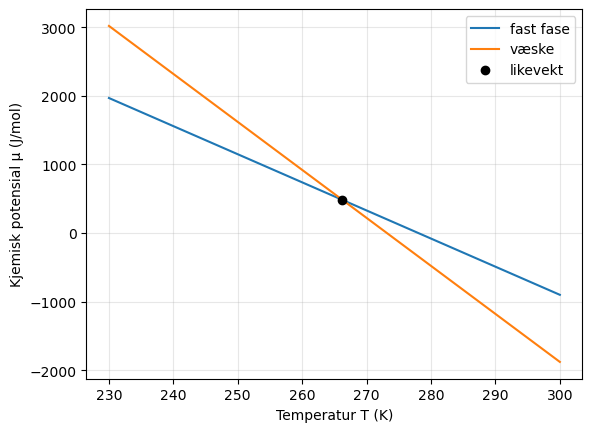

In [252]:
import numpy as np
import matplotlib.pyplot as plt

def halveringsmetoden(f, a, b, tol=1E-10, maks_iterasjoner=100):
    m = (a + b)/2
    i = 0
    while i < maks_iterasjoner and abs(f(m)) > tol:
        if f(a)*f(m) < 0:
            b = m
        else:
            a = m
        m = (a + b)/2
        i += 1
    return m

# Kjemisk potensial for to faser: mu(T) = mu0 - S_m*(T - T0)
def mu_fast(T):
    return 200 - 41*(T - 273.15)

def mu_vaeske(T):
    return 0 - 70*(T - 273.15)

# Likevekt: mu_fast = mu_vaeske, altså differansen = 0
def differanse(T):
    return mu_fast(T) - mu_vaeske(T)

T_likevekt = halveringsmetoden(differanse, 200, 400)
print(f"Faseovergang ved T = {T_likevekt:.2f} K")

# Plott av de to potensialene og krysningspunktet
T = np.linspace(230, 300, 200)
plt.plot(T, mu_fast(T), label="fast fase")
plt.plot(T, mu_vaeske(T), label="væske")
plt.plot(T_likevekt, mu_fast(T_likevekt), "ko", label="likevekt")
plt.xlabel("Temperatur T (K)")
plt.ylabel("Kjemisk potensial μ (J/mol)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bestemmelse av standard reaksjonsentalpi fra likevektskonstantens temperaturavhengighet ved lineær tilpasning av van 't Hoff-likningen

Likevektskonstanten $K$ til en reaksjon er målt ved fire temperaturer: ved $T = 298, 320, 340$ og $360\ \text{K}$ er $K$ henholdsvis $5.8 \times 10^5, 8.0 \times 10^4, 1.6 \times 10^4$ og $4.0 \times 10^3$. På integrert form er van 't Hoff-likningen en rett linje: $\ln K = -\frac{\Delta_r H^\circ}{R}\cdot\frac{1}{T} + \text{konstant}$. Vi skal plotte $\ln K$ mot $1/T$, tilpasse en rett linje, og finne standard reaksjonsentalpi $\Delta_r H^\circ$ fra stigningstallet.

drH = -71.7 kJ/mol


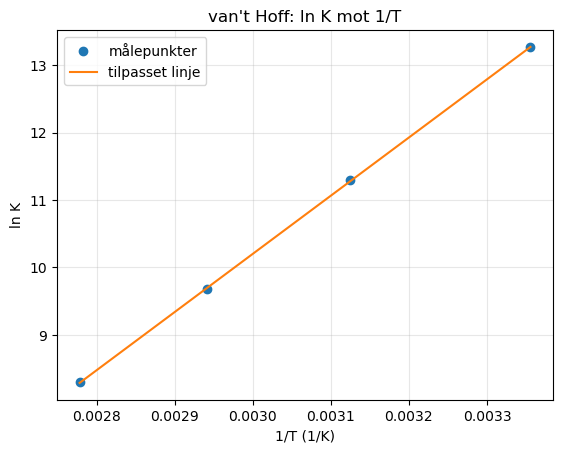

In [253]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314   # gasskonstanten, J/(mol K)

# Målt likevektskonstant ved noen temperaturer
Tdata = np.array([298, 320, 340, 360])           # K
Kdata = np.array([5.8e5, 8.0e4, 1.6e4, 4.0e3])    # dimensjonsløs

# van't Hoff på lineær form: ln K = -(drH/R)(1/T) + konstant
x = 1/Tdata
y = np.log(Kdata)
slope, intercept = np.polyfit(x, y, 1)

# Reaksjonsentalpi fra stigningstallet
drH = -slope*R
print(f"drH = {drH/1000:.1f} kJ/mol")

plt.plot(x, y, "o", label="målepunkter")
plt.plot(x, slope*x + intercept, label="tilpasset linje")
plt.xlabel("1/T (1/K)")
plt.ylabel("ln K")
plt.title("van't Hoff: ln K mot 1/T")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Numerisk bestemmelse av likevektssammensetningen ved å minimere Gibbs-energien som funksjon av reaksjonens ekstent

For reaksjonen $A \rightleftharpoons B$ kan Gibbs-energien skrives som funksjon av ekstenten $\xi$ (andelen omdannet), her i enheter av $RT$: $G(\xi)/RT = \xi\ln\xi + (1-\xi)\ln(1-\xi) + \xi\cdot\frac{\Delta_r G^\circ}{RT}$, der $\Delta_r G^\circ = -RT\ln K$. Systemet er i likevekt der Gibbs-energien er lavest. Vi skal regne ut $G(\xi)$ over hele intervallet og finne minimumet numerisk, og bekrefte at det stemmer med den analytiske likevekten $\xi = K/(1+K)$.

xi ved likevekt (numerisk) = 0.800
xi analytisk K/(1+K)       = 0.800


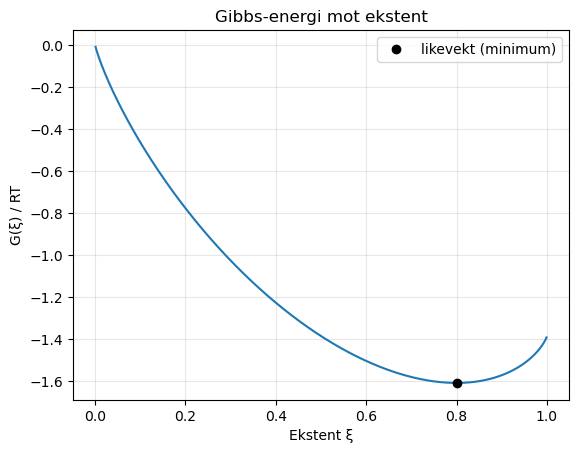

In [254]:
import numpy as np
import matplotlib.pyplot as plt

K = 4.0                          # likevektskonstant
drG0_over_RT = -np.log(K)        # drG0/RT = -ln K

# Gibbs-energi som funksjon av ekstent xi (i enheter av RT), for A <-> B
def G(xi):
    return xi*np.log(xi) + (1-xi)*np.log(1-xi) + xi*drG0_over_RT

# Regn ut G for mange xi-verdier og finn minimumet numerisk
xi = np.linspace(0.001, 0.999, 999)
Gverdier = G(xi)
xi_eq = xi[np.argmin(Gverdier)]

print(f"xi ved likevekt (numerisk) = {xi_eq:.3f}")
print(f"xi analytisk K/(1+K)       = {K/(1+K):.3f}")

plt.plot(xi, Gverdier)
plt.plot(xi_eq, G(xi_eq), "ko", label="likevekt (minimum)")
plt.xlabel("Ekstent ξ")
plt.ylabel("G(ξ) / RT")
plt.title("Gibbs-energi mot ekstent")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Numerisk løsning av hastighetsloven for første orden med Eulers metode og sammenligning med den eksakte integrerte loven

En hastighetslov er en differensiallikning: for en førsteordens reaksjon $A \rightarrow$ produkter er $\frac{d[A]}{dt} = -k_r[A]$. Vi skal løse denne numerisk med Eulers metode, som tar små steg framover i tid: $[A]_{ny} = [A] + \frac{d[A]}{dt}\cdot\Delta t$. Bruk $k_r = 0.3\ \text{s}^{-1}$ og $[A]_0 = 1.0\ \text{mol/L}$, og sammenlign den numeriske løsningen med den eksakte integrerte loven $[A] = [A]_0 e^{-k_r t}$.

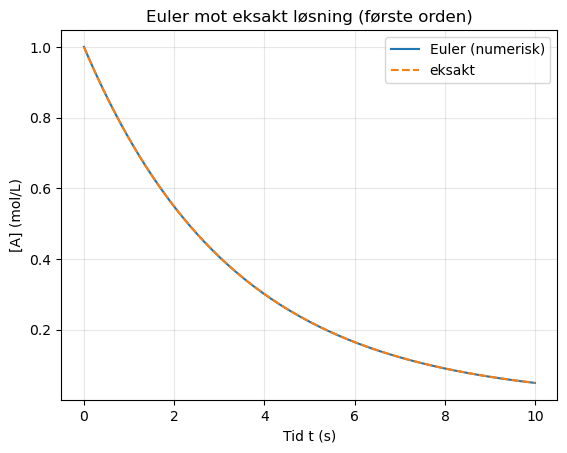

In [255]:
import numpy as np
import matplotlib.pyplot as plt

kr = 0.3       # hastighetskonstant, 1/s
A0 = 1.0       # startkonsentrasjon, mol/L
dt = 0.01      # tidssteg, s
N = 1000       # antall steg

# Eulers metode: ta små steg framover i tid
t_liste = []
A_liste = []
t = 0
A = A0
for i in range(N):
    t_liste.append(t)
    A_liste.append(A)
    dAdt = -kr*A               # hastighetsloven
    A = A + dAdt*dt            # ett Euler-steg
    t = t + dt

# Sammenlign med den eksakte løsningen
t_arr = np.array(t_liste)
plt.plot(t_liste, A_liste, label="Euler (numerisk)")
plt.plot(t_arr, A0*np.exp(-kr*t_arr), "--", label="eksakt")
plt.xlabel("Tid t (s)")
plt.ylabel("[A] (mol/L)")
plt.title("Euler mot eksakt løsning (første orden)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Numerisk simulering av reaksjonsmekanismen A → I → P og visualisering av mellomproduktets forløp

En reaksjon som går via et mellomprodukt, $A \rightarrow I \rightarrow P$, beskrives av tre koblede differensiallikninger: $\frac{d[A]}{dt} = -k_1[A]$, $\frac{d[I]}{dt} = k_1[A] - k_2[I]$ og $\frac{d[P]}{dt} = k_2[I]$. Vi skal løse dem samtidig med Eulers metode ($k_1 = 1.0\ \text{s}^{-1}$, $k_2 = 0.5\ \text{s}^{-1}$, $[A]_0 = 1.0\ \text{mol/L}$) og plotte hvordan de tre konsentrasjonene utvikler seg. Legg merke til hvordan $[I]$ først stiger og så synker.

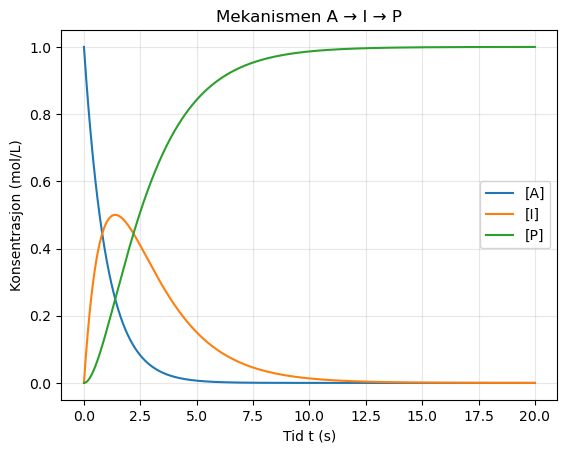

In [256]:
import numpy as np
import matplotlib.pyplot as plt

k1 = 1.0       # A -> I, 1/s
k2 = 0.5       # I -> P, 1/s
dt = 0.001     # tidssteg, s
N = 20000      # antall steg

A = 1.0        # startkonsentrasjoner, mol/L
I = 0.0
P = 0.0

t_liste = []; A_liste = []; I_liste = []; P_liste = []
t = 0
for i in range(N):
    t_liste.append(t); A_liste.append(A); I_liste.append(I); P_liste.append(P)
    # de tre hastighetslovene
    dA = -k1*A
    dI = k1*A - k2*I
    dP = k2*I
    # ett Euler-steg for hver
    A = A + dA*dt
    I = I + dI*dt
    P = P + dP*dt
    t = t + dt

plt.plot(t_liste, A_liste, label="[A]")
plt.plot(t_liste, I_liste, label="[I]")
plt.plot(t_liste, P_liste, label="[P]")
plt.xlabel("Tid t (s)")
plt.ylabel("Konsentrasjon (mol/L)")
plt.title("Mekanismen A → I → P")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bestemmelse av reaksjonsorden og hastighetskonstant ved lineær tilpasning av konsentrasjon–tid-data

For en førsteordens reaksjon er $\ln[A]$ en lineær funksjon av tiden: $\ln[A] = \ln[A]_0 - k_r t$. Er reaksjonen første orden, gir altså et plott av $\ln[A]$ mot $t$ en rett linje, og stigningstallet er $-k_r$. Konsentrasjonen er målt ved $t = 0, 10, 20, 30, 40$ og $50\ \text{s}$. Vi skal plotte $\ln[A]$ mot tiden, tilpasse en rett linje, og finne hastighetskonstanten $k_r$ fra stigningstallet.

kr = 0.0302 1/s


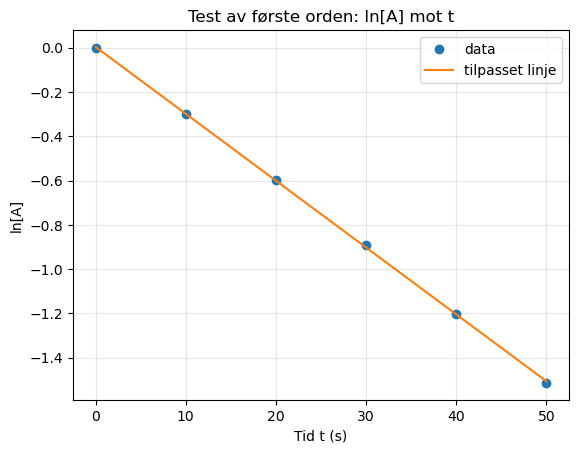

In [257]:
import numpy as np
import matplotlib.pyplot as plt

# Målt konsentrasjon som funksjon av tid
t = np.array([0, 10, 20, 30, 40, 50])                    # s
A = np.array([1.00, 0.74, 0.55, 0.41, 0.30, 0.22])       # mol/L

# Test første orden: ln[A] mot t skal gi en rett linje
slope, intercept = np.polyfit(t, np.log(A), 1)

# Hastighetskonstanten fra stigningstallet (-kr)
kr = -slope
print(f"kr = {kr:.4f} 1/s")

plt.plot(t, np.log(A), "o", label="data")
plt.plot(t, slope*t + intercept, label="tilpasset linje")
plt.xlabel("Tid t (s)")
plt.ylabel("ln[A]")
plt.title("Test av første orden: ln[A] mot t")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bestemmelse av aktiveringsenergien fra hastighetskonstantens temperaturavhengighet ved lineær tilpasning av Arrhenius-likningen

Arrhenius-likningen $k_r = A e^{-E_a/RT}$ beskriver hvordan hastighetskonstanten øker med temperaturen. På logaritmisk form er den lineær: $\ln k_r = \ln A - \frac{E_a}{R}\cdot\frac{1}{T}$. Hastighetskonstanten er målt ved $T = 300, 320, 340$ og $360\ \text{K}$. Vi skal plotte $\ln k_r$ mot $1/T$, tilpasse en rett linje, og finne aktiveringsenergien $E_a$ fra stigningstallet.

Ea = 75.0 kJ/mol


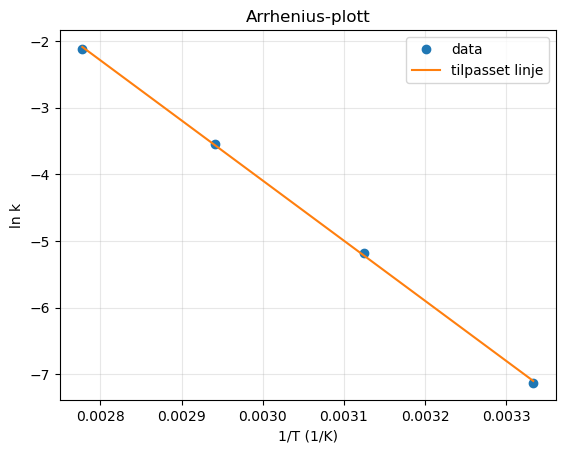

In [258]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314   # gasskonstanten, J/(mol K)

# Målt hastighetskonstant ved noen temperaturer
T = np.array([300, 320, 340, 360])                       # K
k = np.array([8.0e-4, 5.6e-3, 2.9e-2, 1.2e-1])           # 1/s

# Arrhenius på lineær form: ln k = ln A - (Ea/R)(1/T)
slope, intercept = np.polyfit(1/T, np.log(k), 1)

# Aktiveringsenergien fra stigningstallet (-Ea/R)
Ea = -slope*R
print(f"Ea = {Ea/1000:.1f} kJ/mol")

plt.plot(1/T, np.log(k), "o", label="data")
plt.plot(1/T, slope*(1/T) + intercept, label="tilpasset linje")
plt.xlabel("1/T (1/K)")
plt.ylabel("ln k")
plt.title("Arrhenius-plott")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Beregning av reaksjonshastigheten fra konsentrasjon–tid-data ved numerisk derivasjon

Reaksjonshastigheten er $v = -\frac{d[A]}{dt}$. Når vi har målt $[A]$ ved noen tidspunkter, kan vi regne ut denne deriverte numerisk med `np.gradient`, som bruker sentraldifferansen. Konsentrasjonen er målt ved $t = 0, 10, 20, 30, 40$ og $50\ \text{s}$. Vi skal regne ut hastigheten ved hvert tidspunkt og plotte den mot tiden.

v = [0.026  0.0225 0.0165 0.0125 0.0095 0.008 ] mol/(L s)


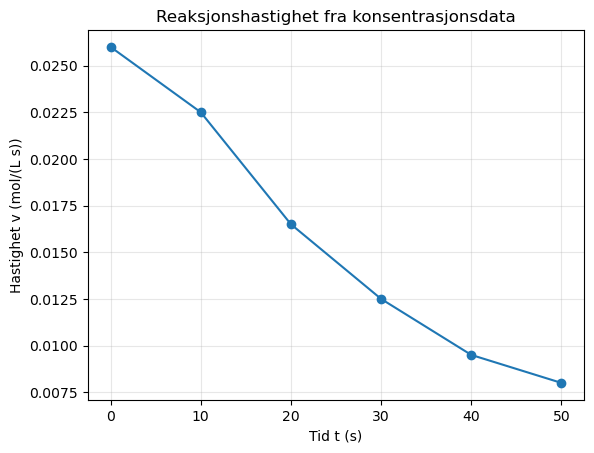

In [259]:
import numpy as np
import matplotlib.pyplot as plt

# Målt konsentrasjon som funksjon av tid
t = np.array([0, 10, 20, 30, 40, 50], dtype=float)       # s
A = np.array([1.00, 0.74, 0.55, 0.41, 0.30, 0.22])       # mol/L

# Reaksjonshastighet v = -d[A]/dt, regnet numerisk med np.gradient
v = -np.gradient(A, t)
print("v =", np.round(v, 4), "mol/(L s)")

plt.plot(t, v, "o-")
plt.xlabel("Tid t (s)")
plt.ylabel("Hastighet v (mol/(L s))")
plt.title("Reaksjonshastighet fra konsentrasjonsdata")
plt.grid(alpha=0.3)
plt.show()

# Numerisk bestemmelse av halveringstiden ved å løse konsentrasjonslikningen som et nullpunktsproblem

Halveringstiden $t_{1/2}$ er tiden det tar før konsentrasjonen er halvert, altså der $[A](t) = \frac{1}{2}[A]_0$. For en førsteordens reaksjon er $[A](t) = [A]_0 e^{-k_r t}$. Vi skal formulere dette som et nullpunktsproblem, $f(t) = [A]_0 e^{-k_r t} - \frac{1}{2}[A]_0 = 0$, og bruke halveringsmetoden til å finne $t_{1/2}$ ($k_r = 0.03\ \text{s}^{-1}$). Sammenlign med den analytiske $t_{1/2} = \ln 2 / k_r$.

In [260]:
import numpy as np

def halveringsmetoden(f, a, b, tol=1E-10, maks_iterasjoner=100):
    m = (a + b)/2
    i = 0
    while i < maks_iterasjoner and abs(f(m)) > tol:
        if f(a)*f(m) < 0:
            b = m
        else:
            a = m
        m = (a + b)/2
        i += 1
    return m

kr = 0.03      # hastighetskonstant, 1/s
A0 = 1.0       # startkonsentrasjon, mol/L

# Nullpunktsproblem: [A](t) - halve startkonsentrasjonen = 0
def f(t):
    return A0*np.exp(-kr*t) - A0/2

t_halv = halveringsmetoden(f, 0, 200)
print(f"t_halv numerisk   = {t_halv:.2f} s")
print(f"t_halv = ln2/kr   = {np.log(2)/kr:.2f} s")

t_halv numerisk   = 23.10 s
t_halv = ln2/kr   = 23.10 s
